In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 7** - Optimizing an ML model with 6 hyperparameters

- This function is about optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers.

- The function you’re **maximising** is the **model’s performance score** (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function.

- This week I will be basing my initial model based on random search and a stratgic model.
  - The straegic model will have an GP regressor and acquisition function.
    - I aim to base the parameters by researching best practices or literature to guide your initial search space.
- **Goal** - find the combination of hyperparameters that yields the highest possible performance.

- **Input** - 6D (30,6)
- **Output** - 6D (30,)

- **Goal** - Maximisation


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_7\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_7\initial_outputs.npy')

In [3]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.001234, 0.887611, 0.445322, 0.221098, 0.990123, 0.556712], dtype=np.float64)
Y_w1_new_point = np.array([0.11990280946929324], dtype=np.float64)

# Append the new data points
X_updated = np.vstack((X, X_w1_new_point))
Y_updated = np.append(Y, Y_w1_new_point)

# Save the updated arrays
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_7\initial_inputs.npy', X_updated)
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_7\initial_outputs.npy', Y_updated)

In [4]:
print("Updated Inputs (X) - Function 7: ", X_updated)
print("Updated Outputs (Y) - Function 7: ", Y_updated)

Updated Inputs (X) - Function 7:  [[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]


### **Interpretation of the output and next steps**


- With 6 hyperparameters and a score of 0.120, I am starting to see the vanishing gradient problem typical of high-dimensional spaces.
  - In the real world, this means the ML model is barely performing better than chance, which might be refelective that this is based on a random search.
- Because this space is vast, random search is fundamentally obsolete here.
  - Therefore, I am going to move to Matérn 5/2 kernel in order to find the performance cliffs where accuracy suddenly spikes.


### **Bayesian Optimisation** - Matern 5/2 kernel and

- I am going to stick to the original approach I decided to use for Week 1 - Strategic Approach, as it was well researched.

- The industry standard for HPO.
  - However, I believe that as a basis it might be useful to try out Matérn 5/2 as it is twice-differentiable, smooth enough for optimization but rough enough to capture "discrete cliffs".

- Furthermore, I would like to use the [0.5]\*6 length scale which makes us question each hyperparameter individually to assess the impact of each on the overall function.
  - The 0.5 value refelects that the prior belief that the model's performance doesn't change instantly with every tiny tweak, but it also doesn't stay the same across the whole range.

- **The alpha = 1e-6** - regularization for matrix stability as fouund in my research.

- Additionally, I have used `n_researts_optimizer=20` to creates a multi-start to find global length scale.


In [5]:
kernel = Matern(length_scale=[0.5]*6, nu=2.5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    alpha=1e-6,
    normalize_y=True,
    random_state=42
)

model.fit(X_updated, Y_updated)

GaussianProcessRegressor(alpha=1e-06,
                         kernel=Matern(length_scale=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5], nu=2.5),
                         n_restarts_optimizer=20, normalize_y=True,
                         random_state=42)

### **Acquisition Function** - Expected Improvement (EI)


I will be using a numerically stable expected improvemet model.

- I am doing this as it often suffers from vanishing gradients in 6d.

- I have choosen to evaluate 1024 point initially for the first 2 weeks using a quasi-random grid.


In [6]:
def expected_improvement(x_grid, model, y_max, xi=0.01):
    mu, sigma = model.predict(x_grid, return_std=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / (sigma + 1e-9)
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei.ravel()

y_max = np.max(Y_updated)
x_grid = np.random.uniform(0, 1, size=(1024, 6))
ei_values = expected_improvement(x_grid, model, y_max)

best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 7 - Bayesian Optimisation (EI): "
        f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}")

Next Submission for Function 7 - Bayesian Optimisation (EI): 0.017847-0.815326-0.270978-0.212167-0.499065-0.497593


### **Visualisation Progress Tracking and Search Map**


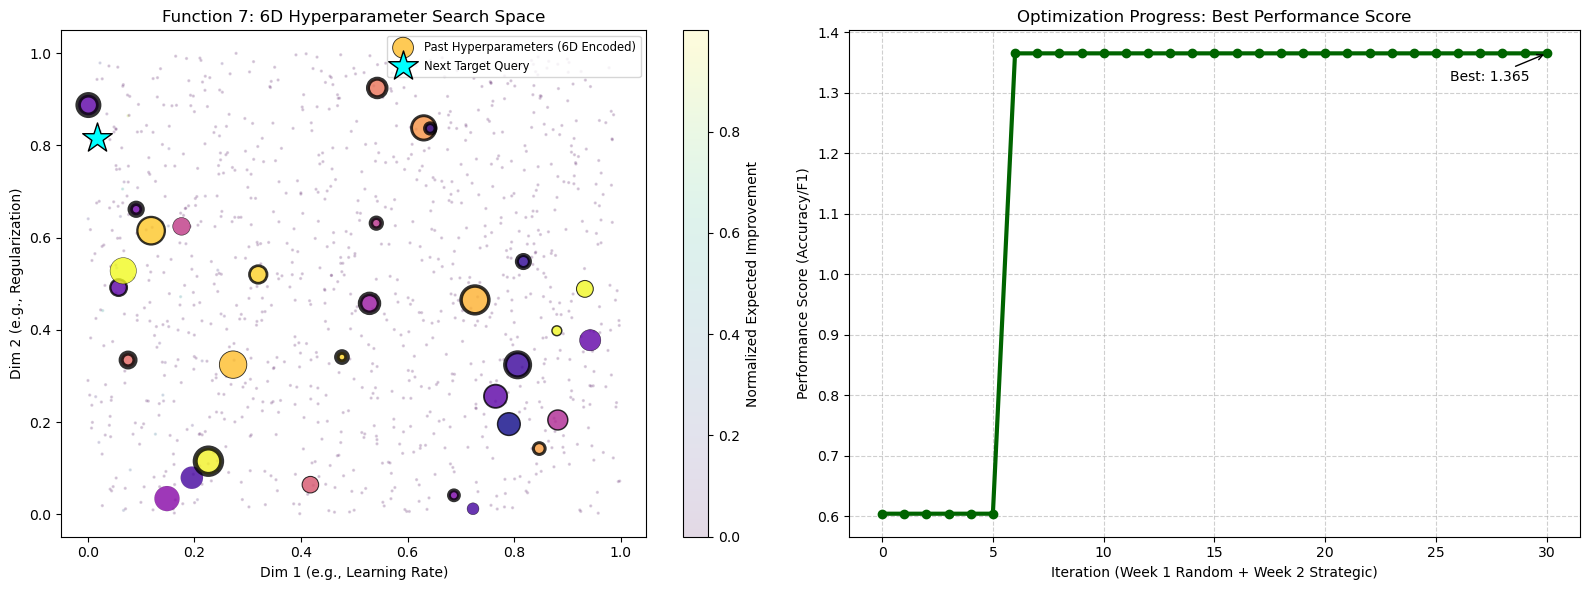

In [7]:
# 1. Setup Progress Tracking
# Function 7 maximizes model performance (Accuracy/F1)
running_max = np.maximum.accumulate(Y_updated)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 2. 6D Projection Parameters
# We use X3 for size and X4 for color. X5 and X6 are visually represented 
# through marker edge thickness and alpha respectively.
x3_scaled = (X_updated[:, 2] - np.min(X_updated[:, 2])) / (np.ptp(X_updated[:, 2]) + 1e-12)
past_sizes = 50 + (350 * x3_scaled) 

# 3. The Search Map: 6D Projected View
# Background: The EI acquisition surface (using Dim 1 and 2 from your x_grid)
acq_norm = (ei_values - np.nanmin(ei_values)) / (np.nanmax(ei_values) - np.nanmin(ei_values) + 1e-12)

# Scatter plot of the 1024 quasi-random grid points evaluated by your model
sc = ax1.scatter(x_grid[:, 0], x_grid[:, 1], c=acq_norm, cmap='viridis', s=2, alpha=0.15)
cbar = plt.colorbar(sc, ax=ax1, label='Normalized Expected Improvement')

# Past Samples: Encoded with 4 additional dimensions
# Color=X4, Size=X3, EdgeWeight=X5, Alpha=X6
past_sc = ax1.scatter(X_updated[:, 0], X_updated[:, 1], 
                      c=X_updated[:, 3], 
                      cmap='plasma', 
                      s=past_sizes, 
                      edgecolors='black', 
                      linewidth=X_updated[:, 4] * 4, 
                      alpha=0.8, 
                      label='Past Hyperparameters (6D Encoded)')

# Next Query: The target point found by your EI model
ax1.scatter(next_query[0], next_query[1], c='cyan', marker='*', s=500, edgecolors='black', label='Next Target Query')

ax1.set_title('Function 7: 6D Hyperparameter Search Space')
ax1.set_xlabel('Dim 1 (e.g., Learning Rate)')
ax1.set_ylabel('Dim 2 (e.g., Regularization)')
ax1.legend(loc='upper right', fontsize='small')

# 4. Progress Plot: Climbing out of the Vanishing Gradient
ax2.plot(running_max, color='darkgreen', linewidth=3, marker='o', markersize=6)
ax2.set_title('Optimization Progress: Best Performance Score')
ax2.set_xlabel('Iteration (Week 1 Random + Week 2 Strategic)')
ax2.set_ylabel('Performance Score (Accuracy/F1)')
ax2.grid(True, linestyle='--', alpha=0.6)

# Annotate current best
ax2.annotate(f'Best: {np.max(Y_updated):.3f}', 
             xy=(len(Y_updated)-1, np.max(Y_updated)), 
             xytext=(-70, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()